# CW2 reference solution — `HighHealthBurden`

**Instructor-facing.** This notebook walks the improvement ladder that CW2 asks
students to discover, measuring every rung so that the payoff for each change is
visible and quantified. It serves three purposes:

1. **Validation** — evidence that the dataset is fit for purpose. If a rung stopped
   paying off, the assignment built on it would be unsound. (`validate_ml_ladder.py`
   asserts the same properties non-interactively.)
2. **A marking reference** — a worked example of the depth a strong submission can
   reach, and where the genuinely hard findings are.
3. **A benchmark** — the closing numbers are the "here is what I got, try to beat
   this" target.

The ladder, in order: crude baseline → data quality → scaling → class imbalance →
hyperparameter tuning → validation method → a more expressive model → decision
thresholds and cost → leakage → overfitting → distribution shift.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, roc_auc_score, confusion_matrix)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from costs import (COST_EMPLOYER, COST_PUBLIC_HEALTH, COST_MATRICES,
                   cost_per_person, optimal_threshold, confusion_counts)

RANDOM_STATE = 42
TARGET = 'HighHealthBurden'

# Chart styling: recessive grid and axes, ink for text, colour reserved for data.
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, MUTED = '#0b0b0b', '#898781'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#52514e', 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 110, 'legend.frameon': False,
})

ladder = []   # every rung's headline numbers, collected for the summary table

### Shared helpers

`encode` is shared with the starter notebook. `naive_clean` reproduces what the
starter does; `careful_clean` is the version a student should arrive at.

In [2]:
ORDINAL_SCALES = {
    'Stress Level': ['Low', 'Medium', 'High'],
    'Physical Activity Level': ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'],
    'Sleep Quality': ['Poor', 'Fair', 'Good', 'Excellent'],
    'Health Issues': ['No Issues', 'Mild', 'Moderate', 'Severe'],
    'Smoking Status': ['Never', 'Former', 'Vaper', 'Light Smoker', 'Heavy Smoker'],
    'Alcohol Level': ['Non-Drinker', 'Light', 'Moderate', 'Heavy'],
    'SelfRatedHealth': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
}

def encode(df, keep_self_rated_health=False):
    d = df.copy()
    for column, order in ORDINAL_SCALES.items():
        if column == 'SelfRatedHealth' and not keep_self_rated_health:
            continue
        d[column] = d[column].map({value: i for i, value in enumerate(order)})
    if not keep_self_rated_health:
        d = d.drop(columns=['SelfRatedHealth'])
    d = pd.get_dummies(d, columns=['Country', 'Gender'], drop_first=True)
    y = d.pop(TARGET)
    return d.drop(columns=['ID']).astype(float), y

def naive_clean(df):
    """The starter notebook's approach: drop duplicates, drop any incomplete row."""
    return df.drop_duplicates().dropna()

def careful_clean(df):
    """Repair the anomalies instead of discarding the rows; impute instead of dropping."""
    d = df.drop_duplicates().copy()
    age_typo = d['Age'] > 100                     # a doubled digit: 34 -> 344
    d.loc[age_typo, 'Age'] = d.loc[age_typo, 'Age'].map(lambda v: int(str(int(v))[:-1]))
    bmi_typo = d['BMI'] > 60                      # a missed decimal point: 24.5 -> 245
    d.loc[bmi_typo, 'BMI'] = (d.loc[bmi_typo, 'BMI'] / 10).round(1)
    for column in d.columns:
        if d[column].isna().any():
            fill = d[column].median() if d[column].dtype != object else d[column].mode()[0]
            d[column] = d[column].fillna(fill)
    return d

def metrics(y_true, y_pred, y_prob=None):
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'cost_agency': cost_per_person(y_true, y_pred, COST_PUBLIC_HEALTH),
        'cost_employer': cost_per_person(y_true, y_pred, COST_EMPLOYER),
    }
    out['auc'] = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    return out

def record(stage, label, m):
    ladder.append({'stage': stage, 'model': label, **m})
    print(f'{label:<38} acc={m["accuracy"]:.3f}  rec+={m["recall"]:.3f}  '
          f'F1={m["f1"]:.3f}  AUC={m["auc"]:.4f}  '
          f'costA={m["cost_agency"]:+7.1f}  costB={m["cost_employer"]:+7.1f}')
    return m

dev_raw = pd.read_csv('coffee_health_v3_dev.csv')
test_raw = pd.read_csv('coffee_health_v3_test.csv')
print(f'development {len(dev_raw)} rows   held-out test {len(test_raw)} rows')

development 10040 rows   held-out test 3060 rows


---
## Stage 0 — reproducing the starter baseline

Before improving anything, establish what the starting point actually is. The number
that matters is not the accuracy: it is the confusion matrix underneath it.

In [3]:
dev_naive = naive_clean(dev_raw)
X_naive, y_naive = encode(dev_naive, keep_self_rated_health=True)   # starter keeps everything
Xtr0, Xva0, ytr0, yva0 = train_test_split(X_naive, y_naive, test_size=0.2,
                                          random_state=RANDOM_STATE)

majority_accuracy = 1 - yva0.mean()
print(f'rows after naive cleaning: {len(dev_naive)} of {len(dev_raw)} '
      f'({len(dev_naive)/len(dev_raw):.0%})')
print(f'predict-everyone-negative accuracy: {majority_accuracy:.3f}\n')

for label, model in [('LogisticRegression() default', LogisticRegression()),
                     ('KNeighborsClassifier() default', KNeighborsClassifier())]:
    model.fit(Xtr0, ytr0)
    pred = model.predict(Xva0)
    m = record('0 starter', label, metrics(yva0, pred, model.predict_proba(Xva0)[:, 1]))
    counts = confusion_counts(yva0, pred)
    print(f'{"":38}   TN={counts["TN"]} FP={counts["FP"]} FN={counts["FN"]} TP={counts["TP"]}')

rows after naive cleaning: 7385 of 10040 (74%)
predict-everyone-negative accuracy: 0.802

LogisticRegression() default           acc=0.797  rec+=0.014  F1=0.026  AUC=0.8055  costA= +283.1  costB= +156.3
                                         TN=1173 FP=11 FN=289 TP=4


KNeighborsClassifier() default         acc=0.766  rec+=0.058  F1=0.089  AUC=0.4927  costA= +271.2  costB= +169.5
                                         TN=1114 FP=70 FN=276 TP=17


**The finding.** Logistic regression reports around 80% accuracy and identifies *nobody*.
It is exactly as accurate as a single line of code that predicts "no" for every person,
and it would leave every single high-burden case without an invitation. KNN scores
*below* the majority-class baseline while finding a handful of cases.

This is why accuracy is the wrong headline metric on an imbalanced problem, and why the
cost columns are in the starter notebook from the first run: at roughly €283 per person,
the public health agency is being handed close to the worst outcome available to it.

---
## Stage 1 — data quality, done properly

Two separate mistakes in the starter: it *drops* rows containing a missing value
(discarding a quarter of the data), and it leaves the anomalies in place. Both age
typos and BMI decimal-point errors are exactly recoverable.

In [4]:
dev_clean = careful_clean(dev_raw)
print(f'age anomalies repaired: {(dev_raw["Age"] > 100).sum()}')
print(f'BMI anomalies repaired: {(dev_raw["BMI"] > 60).sum()}')
print(f'rows retained: naive {len(dev_naive)}  vs  careful {len(dev_clean)} '
      f'(+{len(dev_clean)/len(dev_naive) - 1:.0%})')

# Were the rows the starter discards a random sample? Missingness in the
# device-sourced fields rises with age, so dropping them is not neutral.
dropped = dev_raw[dev_raw.isna().any(axis=1)]
kept = dev_raw.dropna()
print(f'\nrows the starter discards: {len(dropped)}')
print(f'  mean age       dropped {dropped["Age"].where(dropped["Age"] <= 100).mean():.1f}'
      f'  vs kept {kept["Age"].where(kept["Age"] <= 100).mean():.1f}')
print(f'  positive rate  dropped {dropped[TARGET].mean():.3f}'
      f'  vs kept {kept[TARGET].mean():.3f}')

# From here on SelfRatedHealth is excluded -- see Stage 8 for why.
X, y = encode(dev_clean)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

lr_clean = LogisticRegression(max_iter=2000).fit(X_train, y_train)
record('1 cleaned', 'LR, repaired + imputed, unscaled',
       metrics(y_val, lr_clean.predict(X_val), lr_clean.predict_proba(X_val)[:, 1]))

age anomalies repaired: 71
BMI anomalies repaired: 56
rows retained: naive 7385  vs  careful 10000 (+35%)

rows the starter discards: 2627
  mean age       dropped 42.9  vs kept 39.9
  positive rate  dropped 0.204  vs kept 0.195
LR, repaired + imputed, unscaled       acc=0.802  rec+=0.000  F1=0.000  AUC=0.4615  costA= +287.1  costB= +154.4


{'accuracy': 0.802,
 'balanced_acc': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'cost_agency': 287.1,
 'cost_employer': 154.44,
 'auc': 0.4614867502959773}

Does the extra data actually buy anything? Isolate it: identical models and settings,
the only difference being how the data was cleaned, scored on the held-out test set so
the comparison is not itself an artefact of one split.

In [5]:
X_test_probe, y_test_probe = encode(test_raw)
for label, cleaner in [('naive (drop rows)', naive_clean),
                       ('careful (repair + impute)', careful_clean)]:
    frame = cleaner(dev_raw)
    Xc, yc = encode(frame)
    Xt = X_test_probe.reindex(columns=Xc.columns, fill_value=0)
    sc = StandardScaler().fit(Xc)
    lr_probe = LogisticRegression(max_iter=2000, class_weight='balanced').fit(sc.transform(Xc), yc)
    gbm_probe = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(Xc, yc)
    print(f'{label:<28} n={len(frame):>6}   test AUC   '
          f'LR {roc_auc_score(y_test_probe, lr_probe.predict_proba(sc.transform(Xt))[:, 1]):.4f}'
          f'   GBM {roc_auc_score(y_test_probe, gbm_probe.predict_proba(Xt)[:, 1]):.4f}')

naive (drop rows)            n=  7385   test AUC   LR 0.7903   GBM 0.8691


careful (repair + impute)    n= 10000   test AUC   LR 0.7732   GBM 0.8741


**The findings, including an inconvenient one.**

Careful cleaning recovers around a third more training data, and the rows the starter
discarded were **not** a random sample: missingness in the device-sourced fields rises
with age, so dropping them systematically removed older respondents — the group at
highest risk. That is a real argument against reaching for `dropna()`.

But measured honestly, the payoff is small and **not uniform across models**. The
gradient boosting model gains a little test AUC from the extra rows; logistic regression
is slightly *worse* with them. And on the unscaled model above the headline metric does
not move at all — it is still predicting "no" for everybody, so better data has nothing
to act through yet.

This is worth stating plainly, because students tend to assume that every defensible
improvement must show up as a bigger number. Some only pay off once another part of the
pipeline is fixed. Some are justified on grounds of **bias** rather than accuracy — a
training sample that represents the people the model will be used on is a good enough
reason by itself. Reporting a change that did not move the metric, and arguing for
keeping it anyway, is stronger work than quietly dropping it.

---
## Stage 2 — feature scaling

`Household Income` runs to six figures while `BMI` sits in the twenties. Any model that
measures distance, or that optimises without normalising, is dominated by whichever
feature happens to have the largest numbers.

In [6]:
print('feature ranges before scaling:')
print(X_train[['Household Income', 'Caffeine Intake', 'BMI', 'Avg Sleep Hours Per Night']]
      .agg(['min', 'max']).T.to_string(), '\n')

scaler = StandardScaler().fit(X_train)
S_train, S_val = scaler.transform(X_train), scaler.transform(X_val)

for label, Xa, Xb in [('KNN k=5, unscaled', X_train, X_val),
                      ('KNN k=5, scaled', S_train, S_val)]:
    knn = KNeighborsClassifier().fit(Xa, y_train)
    record('2 scaling', label,
           metrics(y_val, knn.predict(Xb), knn.predict_proba(Xb)[:, 1]))

lr_scaled = LogisticRegression(max_iter=2000).fit(S_train, y_train)
record('2 scaling', 'LR, scaled',
       metrics(y_val, lr_scaled.predict(S_val), lr_scaled.predict_proba(S_val)[:, 1]))

feature ranges before scaling:
                               min       max
Household Income           12000.0  250000.0
Caffeine Intake                0.0     709.8
BMI                           16.0      43.9
Avg Sleep Hours Per Night      3.0       9.7 



KNN k=5, unscaled                      acc=0.775  rec+=0.068  F1=0.107  AUC=0.5249  costA= +265.0  costB= +163.6


KNN k=5, scaled                        acc=0.828  rec+=0.293  F1=0.403  AUC=0.7680  costA= +167.0  costB= +121.2
LR, scaled                             acc=0.830  rec+=0.326  F1=0.431  AUC=0.8224  costA= +153.8  costB= +118.2


{'accuracy': 0.8295,
 'balanced_acc': 0.639811456207965,
 'precision': 0.6354679802955665,
 'recall': 0.32575757575757575,
 'f1': 0.4307178631051753,
 'cost_agency': 153.795,
 'cost_employer': 118.21,
 'auc': 0.8223632837099172}

**The finding.** Unscaled KNN has an AUC near 0.5 — it is guessing. Its nearest
neighbours are simply the people with the most similar income, which is nearly
irrelevant to the outcome, because income differences of tens of thousands swamp every
other feature in the distance calculation. Scaling converts a useless model into a
usable one without changing a single hyperparameter.

Note that logistic regression benefits far less. Scaling is not a universal good; it
matters enormously for distance-based and gradient-based methods and barely at all for
a well-conditioned linear solver. Saying *which* models needed it, and why, is worth
more than applying it everywhere by reflex.

---
## Stage 3 — class imbalance

Only about one person in five has a high-burden year, so a model minimising overall
error is rewarded for ignoring them. Two standard remedies, compared.

In [7]:
record('3 imbalance', 'LR scaled, no weighting',
       metrics(y_val, lr_scaled.predict(S_val), lr_scaled.predict_proba(S_val)[:, 1]))

lr_balanced = LogisticRegression(max_iter=2000, class_weight='balanced').fit(S_train, y_train)
record('3 imbalance', 'LR scaled + class_weight',
       metrics(y_val, lr_balanced.predict(S_val), lr_balanced.predict_proba(S_val)[:, 1]))

# SMOTE is fitted on the TRAINING data only. Resampling the validation or test set
# would mean measuring performance on a population that does not exist.
S_smote, y_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(S_train, y_train)
print(f'\nSMOTE resampled training set: {len(y_train)} -> {len(y_smote)} rows, '
      f'positive rate {y_train.mean():.1%} -> {y_smote.mean():.1%}')
lr_smote = LogisticRegression(max_iter=2000).fit(S_smote, y_smote)
record('3 imbalance', 'LR scaled + SMOTE',
       metrics(y_val, lr_smote.predict(S_val), lr_smote.predict_proba(S_val)[:, 1]))

LR scaled, no weighting                acc=0.830  rec+=0.326  F1=0.431  AUC=0.8224  costA= +153.8  costB= +118.2


LR scaled + class_weight               acc=0.760  rec+=0.755  F1=0.555  AUC=0.8229  costA=   -2.8  costB= +125.5

SMOTE resampled training set: 8000 -> 12834 rows, positive rate 19.8% -> 50.0%
LR scaled + SMOTE                      acc=0.759  rec+=0.742  F1=0.550  AUC=0.8223  costA=   +2.3  costB= +126.8


{'accuracy': 0.759,
 'balanced_acc': 0.7527582558754629,
 'precision': 0.4362017804154303,
 'recall': 0.7424242424242424,
 'f1': 0.5495327102803739,
 'cost_agency': 2.31,
 'cost_employer': 126.82,
 'auc': 0.8223081815662863}

**The finding.** Both remedies move positive-class recall from roughly a third to
roughly three quarters, and both *reduce* headline accuracy. That is the point: the
model is now making a different trade, not a better one in the abstract. Whether the
trade is worth making depends entirely on who is paying, which is what the cost columns
answer — and for the public health agency the cost per person falls dramatically.

Class weighting and SMOTE land in much the same place here. Class weighting is cheaper,
introduces no synthetic records, and leaves the data honest, so it is the better default;
a submission that reaches for SMOTE should say why.

---
## Stage 4 — hyperparameter tuning

Defaults are a guess made by a library author who has never seen your data.

In [8]:
knn_search = GridSearchCV(KNeighborsClassifier(),
                          {'n_neighbors': [5, 15, 25, 45, 75, 105],
                           'weights': ['uniform', 'distance']},
                          scoring='roc_auc', cv=5, n_jobs=-1).fit(S_train, y_train)
print(f'best KNN: {knn_search.best_params_}  (CV AUC {knn_search.best_score_:.4f})')
best_knn = knn_search.best_estimator_
record('4 tuning', f'KNN tuned k={knn_search.best_params_["n_neighbors"]}',
       metrics(y_val, best_knn.predict(S_val), best_knn.predict_proba(S_val)[:, 1]))

lr_search = GridSearchCV(LogisticRegression(max_iter=4000, class_weight='balanced'),
                         {'C': [0.01, 0.1, 1.0, 10.0]},
                         scoring='roc_auc', cv=5, n_jobs=-1).fit(S_train, y_train)
print(f'best LR: {lr_search.best_params_}  (CV AUC {lr_search.best_score_:.4f})')
record('4 tuning', 'LR tuned + class_weight',
       metrics(y_val, lr_search.predict(S_val), lr_search.predict_proba(S_val)[:, 1]))

best KNN: {'n_neighbors': 105, 'weights': 'distance'}  (CV AUC 0.8322)


KNN tuned k=105                        acc=0.818  rec+=0.104  F1=0.184  AUC=0.8535  costA= +243.4  costB= +139.2
best LR: {'C': 0.01}  (CV AUC 0.8076)
LR tuned + class_weight                acc=0.766  rec+=0.760  F1=0.563  AUC=0.8228  costA=   -6.0  costB= +121.7


{'accuracy': 0.7665,
 'balanced_acc': 0.7640904052998816,
 'precision': 0.4472511144130758,
 'recall': 0.76010101010101,
 'f1': 0.5631431244153414,
 'cost_agency': -6.005,
 'cost_employer': 121.73,
 'auc': 0.8227663165319027}

**The finding.** The default `k=5` is badly wrong for this data — the optimum is an order
of magnitude larger. With substantial irreducible noise in the outcome, five neighbours
is mostly sampling that noise; averaging over many more recovers the underlying signal.

Tuning logistic regression's regularisation, by contrast, changes almost nothing. Worth
saying explicitly in a submission: tuning is not uniformly valuable, and knowing which
knobs matter for which model family is the actual skill.

**And a trap worth pausing on.** The tuned KNN has a far better AUC than the default —
but a *worse* recall and a *worse* cost. The grid search optimised `roc_auc` while the
predictions are still being made at a threshold of 0.5, and a model averaging over a
hundred neighbours produces well-ordered but compressed probabilities that rarely cross
0.5. It ranks people well, then decides almost nobody is at risk.

You get what you optimise for. If the decision is what matters, tune against something
that reflects the decision — or fix the threshold, which is Stage 7.

---
## Stage 5 — the validation method

Every number so far came from one 80/20 split with one seed. How much of the difference
between two models is real, and how much is the split?

In [9]:
contenders = {
    'LR balanced':  lambda: LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RF depth 8':   lambda: RandomForestClassifier(n_estimators=120, max_depth=8,
                                                   class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
    'RF depth 14':  lambda: RandomForestClassifier(n_estimators=200, max_depth=14,
                                                   min_samples_leaf=3, class_weight='balanced',
                                                   random_state=RANDOM_STATE, n_jobs=-1),
}
per_seed = {name: [] for name in contenders}
for seed in range(10):
    a, b, c, d = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    sc = StandardScaler().fit(a)
    for name, make in contenders.items():
        model = make().fit(sc.transform(a), c)
        per_seed[name].append(f1_score(d, model.predict(sc.transform(b))))

summary = pd.DataFrame(per_seed).agg(['mean', 'std', 'min', 'max']).T
print(summary.round(4).to_string(), '\n')

wins = sum(1 for x, y_ in zip(per_seed['RF depth 8'], per_seed['RF depth 14']) if x > y_)
print(f'RF depth 8 beats RF depth 14 on {wins}/10 splits '
      f'(means {np.mean(per_seed["RF depth 8"]):.4f} vs {np.mean(per_seed["RF depth 14"]):.4f})')

               mean     std     min     max
LR balanced  0.5328  0.0103  0.5134  0.5448
RF depth 8   0.5800  0.0177  0.5524  0.6080
RF depth 14  0.5802  0.0208  0.5455  0.6140 

RF depth 8 beats RF depth 14 on 6/10 splits (means 0.5800 vs 0.5802)


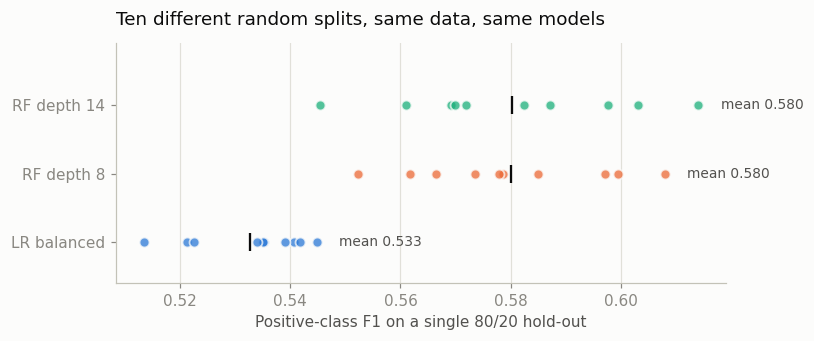

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for i, (name, values) in enumerate(per_seed.items()):
    ax.scatter(values, [i] * len(values), s=42, color=SERIES[i], alpha=0.75,
               edgecolor='#fcfcfb', linewidth=1.2, zorder=3)
    ax.scatter([np.mean(values)], [i], s=150, marker='|', color=INK, zorder=4)
    ax.text(max(values) + 0.004, i, f'mean {np.mean(values):.3f}',
            va='center', fontsize=9, color='#52514e')
ax.set_yticks(range(len(per_seed)), list(per_seed))
ax.set_xlabel('Positive-class F1 on a single 80/20 hold-out')
ax.set_title('Ten different random splits, same data, same models', loc='left', pad=12)
ax.set_ylim(-0.6, len(per_seed) - 0.1)
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**The finding.** The two random forests have essentially identical mean F1, yet on any
single split one of them "wins" — and which one wins depends on the seed. A student who
ran one split and reported a winner would be reporting noise.

The spread within a single model is also wide enough to swamp several of the genuine
improvements measured earlier. This is the argument for cross-validation or repeated
hold-out, made from evidence rather than assertion.

---
## Stage 6 — a more expressive model

Logistic regression assumes every effect is additive and monotonic. Two things in this
data are neither: sleep duration is harmful at both extremes, and coffee intake follows
a J-curve. There are also interactions — smoking and obesity together are worse than
the sum of their parts.

In [11]:
gbm = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
record('5 model', 'HistGradientBoosting (default)',
       metrics(y_val, gbm.predict(X_val), gbm.predict_proba(X_val)[:, 1]))

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
record('5 model', 'RandomForest',
       metrics(y_val, rf.predict(X_val), rf.predict_proba(X_val)[:, 1]))

gbm_search = GridSearchCV(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                          {'max_leaf_nodes': [15, 31, 63], 'learning_rate': [0.05, 0.1],
                           'min_samples_leaf': [20, 50]},
                          scoring='roc_auc', cv=5, n_jobs=-1).fit(X_train, y_train)
print(f'\nbest GBM: {gbm_search.best_params_}  (CV AUC {gbm_search.best_score_:.4f})')
best_gbm = gbm_search.best_estimator_
record('5 model', 'HistGradientBoosting tuned',
       metrics(y_val, best_gbm.predict(X_val), best_gbm.predict_proba(X_val)[:, 1]))

lr_auc = [r for r in ladder if r['model'] == 'LR tuned + class_weight'][0]['auc']
print(f'\nAUC gain of tuned GBM over tuned LR: '
      f'{[r for r in ladder if r["model"] == "HistGradientBoosting tuned"][0]["auc"] - lr_auc:+.4f}')

HistGradientBoosting (default)         acc=0.850  rec+=0.485  F1=0.561  AUC=0.8780  costA=  +87.5  costB=  +97.1


RandomForest                           acc=0.847  rec+=0.374  F1=0.492  AUC=0.8819  costA= +131.7  costB= +105.9



best GBM: {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}  (CV AUC 0.8690)
HistGradientBoosting tuned             acc=0.849  rec+=0.417  F1=0.522  AUC=0.8844  costA= +114.5  costB= +102.0

AUC gain of tuned GBM over tuned LR: +0.0616


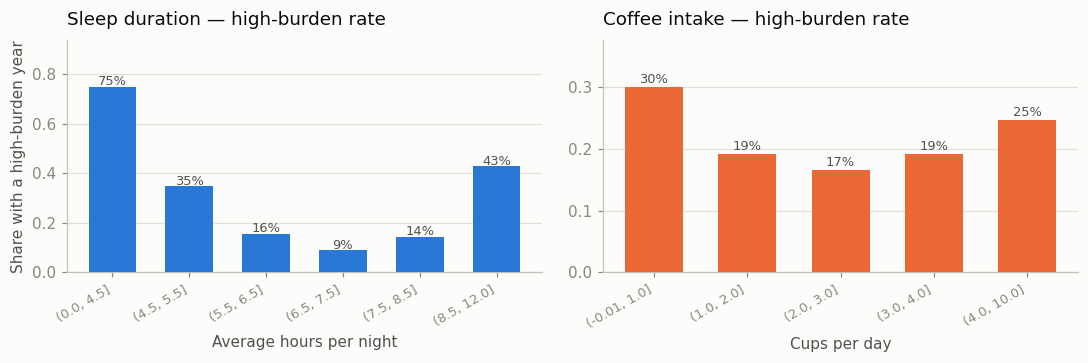

                            mean  size
Avg Sleep Hours Per Night             
(0.0, 4.5]                 0.749   410
(4.5, 5.5]                 0.348  1682
(5.5, 6.5]                 0.156  3874
(6.5, 7.5]                 0.090  2756
(7.5, 8.5]                 0.144  1096
(8.5, 12.0]                0.429   182


In [12]:
# Where does the gain come from? Compare the outcome rate across sleep duration --
# a linear model on raw hours cannot represent a curve with a minimum in the middle.
bins = pd.cut(dev_clean['Avg Sleep Hours Per Night'], [0, 4.5, 5.5, 6.5, 7.5, 8.5, 12])
rate_by_sleep = dev_clean.groupby(bins, observed=True)[TARGET].agg(['mean', 'size'])
cups = pd.cut(dev_clean['Daily Coffees'], [-0.01, 1, 2, 3, 4, 10])
rate_by_coffee = dev_clean.groupby(cups, observed=True)[TARGET].agg(['mean', 'size'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, table, title, xlabel, colour in [
        (axes[0], rate_by_sleep, 'Sleep duration', 'Average hours per night', SERIES[0]),
        (axes[1], rate_by_coffee, 'Coffee intake', 'Cups per day', SERIES[1])]:
    labels = [str(i) for i in table.index]
    ax.bar(range(len(table)), table['mean'], color=colour, width=0.62, zorder=3)
    for i, v in enumerate(table['mean']):
        ax.text(i, v + 0.006, f'{v:.0%}', ha='center', fontsize=8.5, color='#52514e')
    ax.set_xticks(range(len(table)), labels, rotation=30, ha='right', fontsize=8.5)
    ax.set_title(f'{title} — high-burden rate', loc='left', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, max(table['mean']) * 1.25)
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Share with a high-burden year')
plt.tight_layout(); plt.show()

print(rate_by_sleep.round(3).to_string())

**The finding.** Both relationships are U-shaped: the lowest risk sits in the middle of
the range, and rises at both ends. A linear model given raw `Avg Sleep Hours Per Night`
must choose a single direction for the effect and therefore cannot fit either curve;
a tree splits the range and fits both arms.

This is where the gain over logistic regression comes from, and it is a much better
answer than "boosting is a stronger algorithm". A strong submission identifies the
structure and could, in principle, close most of the gap by engineering the right
features for the linear model instead.

---
## Stage 7 — the decision threshold, and who is paying

Every model above turned probabilities into decisions at 0.5. Nothing justifies that
number. The threshold that minimises expected cost follows from the cost matrix:

$$p^* = \frac{C_{FP} - C_{TN}}{(C_{FP} - C_{TN}) + (C_{FN} - C_{TP})}$$

In [13]:
for stakeholder, matrix in COST_MATRICES.items():
    print(f'{stakeholder:<32} optimal threshold {optimal_threshold(matrix):.3f}')

candidates = {
    'GBM tuned':   best_gbm.predict_proba(X_val)[:, 1],
    'LR balanced': lr_search.predict_proba(S_val)[:, 1],
    'KNN tuned':   best_knn.predict_proba(S_val)[:, 1],
}

rows = []
for name, probabilities in candidates.items():
    for stakeholder, matrix in COST_MATRICES.items():
        t = optimal_threshold(matrix)
        rows.append({
            'model': name, 'stakeholder': stakeholder,
            'cost @ 0.5': cost_per_person(y_val, (probabilities >= 0.5).astype(int), matrix),
            'cost @ p*': cost_per_person(y_val, (probabilities >= t).astype(int), matrix),
        })
cost_table = pd.DataFrame(rows)
print('\nEUR per person scored (negative = net benefit):')
print(cost_table.pivot(index='model', columns='stakeholder').round(1).to_string())

Public health agency             optimal threshold 0.077
Employer occupational health     optimal threshold 0.377



EUR per person scored (negative = net benefit):
                              cost @ 0.5                                         cost @ p*                     
stakeholder Employer occupational health Public health agency Employer occupational health Public health agency
model                                                                                                          
GBM tuned                          102.0                114.5                         88.8                -56.8
KNN tuned                          139.2                243.4                        122.8                -47.4
LR balanced                        121.7                 -6.0                        168.7                 -1.9


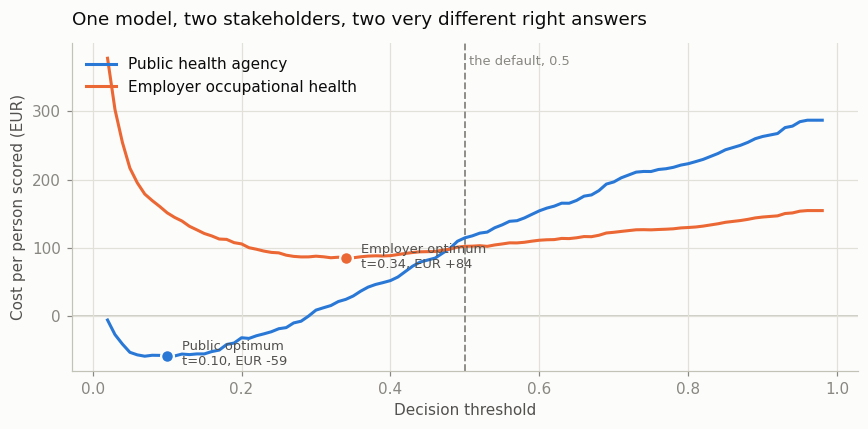

In [14]:
grid = np.linspace(0.02, 0.98, 97)
fig, ax = plt.subplots(figsize=(8, 4))

for i, (stakeholder, matrix) in enumerate(COST_MATRICES.items()):
    curve = [cost_per_person(y_val, (candidates['GBM tuned'] >= t).astype(int), matrix)
             for t in grid]
    ax.plot(grid, curve, color=SERIES[i], linewidth=2, zorder=3, label=stakeholder)
    best = grid[int(np.argmin(curve))]
    ax.scatter([best], [min(curve)], s=70, color=SERIES[i], edgecolor='#fcfcfb',
               linewidth=1.5, zorder=4)
    ax.annotate(f'{stakeholder.split()[0]} optimum\nt={best:.2f}, EUR {min(curve):+.0f}',
                (best, min(curve)), textcoords='offset points', xytext=(10, -6),
                fontsize=8.5, color='#52514e')

ax.axvline(0.5, color=MUTED, linestyle='--', linewidth=1.2, zorder=2)
ax.text(0.505, ax.get_ylim()[1] * 0.92, 'the default, 0.5', fontsize=8.5, color=MUTED)
ax.axhline(0, color='#c3c2b7', linewidth=1, zorder=1)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Cost per person scored (EUR)')
ax.set_title('One model, two stakeholders, two very different right answers',
             loc='left', pad=12)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

**The findings.**

1. **The default threshold is wrong for both stakeholders**, and badly wrong for the
   agency: moving from 0.5 to its cost-optimal threshold swings the agency from paying
   out to making a net saving, without retraining anything.
2. **The two stakeholders disagree about which model to deploy.** At the default
   threshold the agency prefers the class-weighted logistic regression while the
   employer prefers the gradient boosting model — because one buys recall and the other
   buys precision. "Which model is best?" has no answer until someone says *best for
   whom*.
3. The agency's curve is steep on the right and shallow on the left: being too cautious
   is expensive, being too generous is nearly free. The employer's is much flatter,
   because its two error costs are close together.

A strong submission quantifies the disagreement and makes a separate, justified
recommendation to each stakeholder.

---
## Stage 8 — the leakage trap

Every model since Stage 1 has excluded `SelfRatedHealth`. Here is what including it does.

In [15]:
X_leak, y_leak = encode(dev_clean, keep_self_rated_health=True)
XL_train, XL_val, yL_train, yL_val = train_test_split(
    X_leak, y_leak, test_size=0.2, stratify=y_leak, random_state=RANDOM_STATE)

gbm_leak = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(XL_train, yL_train)
leaked = record('6 leakage', 'GBM including SelfRatedHealth',
                metrics(yL_val, gbm_leak.predict(XL_val), gbm_leak.predict_proba(XL_val)[:, 1]))

honest = [r for r in ladder if r['model'] == 'HistGradientBoosting (default)'][0]
print(f'\nAUC      {honest["auc"]:.4f} -> {leaked["auc"]:.4f}   ({leaked["auc"]-honest["auc"]:+.4f})')
print(f'accuracy {honest["accuracy"]:.4f} -> {leaked["accuracy"]:.4f}   '
      f'({leaked["accuracy"]-honest["accuracy"]:+.4f})')
print(f'recall   {honest["recall"]:.4f} -> {leaked["recall"]:.4f}   '
      f'({leaked["recall"]-honest["recall"]:+.4f})')

GBM including SelfRatedHealth          acc=0.877  rec+=0.576  F1=0.650  AUC=0.9080  costA=  +46.7  costB=  +76.7

AUC      0.8780 -> 0.9080   (+0.0300)
accuracy 0.8495 -> 0.8770   (+0.0275)
recall   0.4848 -> 0.5758   (+0.0909)


**The finding.** `SelfRatedHealth` delivers a free and genuinely large improvement. It is
also unusable, for two independent reasons.

**It would not exist at prediction time.** The deployment scenario is scoring people from
routinely held administrative and wearable data. `SelfRatedHealth` comes from the survey,
and the survey is not run on the population either stakeholder wants to screen. A model
that depends on it cannot be deployed at all — the column is simply absent.

**It is a measurement of the thing being predicted.** Self-rated health is well known to
predict later mortality and healthcare use *after* adjusting for every measured risk
factor, because respondents incorporate information no questionnaire captures. That is
exactly why it helps here, and exactly why using it is circular: it is a partial
observation of the outcome dressed up as a feature.

Worth stressing for marking: nothing about the modelling flags this. The pipeline runs,
cross-validation agrees, the test score improves. The only defence is reading the column
list and asking, of each feature, *would I have this, for this person, at the moment I
need to make the decision?*

---
## Stage 9 — overfitting: three different numbers for "how good is it?"

In [16]:
X_full, y_full = X, y
gbm_full = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_full, y_full)

X_test, y_test = encode(test_raw)                       # encoding only -- never cleaned
X_test = X_test.reindex(columns=X_full.columns, fill_value=0)

resubstitution = accuracy_score(y_full, gbm_full.predict(X_full))
cv_scores = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                            X_full, y_full,
                            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                            scoring='accuracy')
test_accuracy = accuracy_score(y_test, gbm_full.predict(X_test))
test_auc = roc_auc_score(y_test, gbm_full.predict_proba(X_test)[:, 1])
cv_auc = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                         X_full, y_full, cv=5, scoring='roc_auc').mean()

print(f'training data (resubstitution)  accuracy {resubstitution:.4f}')
print(f'5-fold cross-validation         accuracy {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})')
print(f'held-out test set               accuracy {test_accuracy:.4f}')
print(f'\noptimism (train - CV):         {resubstitution - cv_scores.mean():+.4f}')
print(f'shift penalty (CV - test):       {cv_scores.mean() - test_accuracy:+.4f}')
print(f'\nAUC: CV {cv_auc:.4f}  vs  test {test_auc:.4f}   ({test_auc - cv_auc:+.4f})')

training data (resubstitution)  accuracy 0.9245
5-fold cross-validation         accuracy 0.8511  (+/- 0.0021)
held-out test set               accuracy 0.8261

optimism (train - CV):         +0.0734
shift penalty (CV - test):       +0.0250

AUC: CV 0.8665  vs  test 0.8741   (+0.0076)


**The findings.**

**Scoring on the training data is meaningless.** Resubstitution accuracy overstates
cross-validated performance by around seven points, because the model has partly
memorised rows it was fitted on. This number should never appear in a report as an
estimate of performance.

**Cross-validation is honest about the development set but still optimistic about the
test set.** The remaining gap is not overfitting — cross-validation already controlled for
that. It is a property of the test set, and Stage 10 takes it apart.

**Accuracy falls while AUC rises.** The model's *ranking* of people by risk is at least as
good on the test set as it was in cross-validation; what changed is that more of the test
population is genuinely high-risk, so a fixed threshold converts that ranking into more
errors, and the majority-class baseline is harder to beat. Reporting only accuracy makes
the test set look like a model failure. It is not.

---
## Stage 10 — is the test set representative?

The deepest layer, and where the highest marks are. The gap has three separable causes.

In [17]:
comparison = pd.DataFrame({
    'development': [len(dev_raw), dev_raw[TARGET].mean(),
                    dev_raw['Age'].where(dev_raw['Age'] <= 100).mean(),
                    (dev_raw['Country'] == 'UK').mean(),
                    (dev_raw['Smoking Status'] == 'Vaper').mean(),
                    dev_raw.duplicated().mean(),
                    (dev_raw['Age'] > 100).mean(), (dev_raw['BMI'] > 60).mean(),
                    dev_raw.isna().any(axis=1).mean()],
    'test': [len(test_raw), test_raw[TARGET].mean(),
             test_raw['Age'].where(test_raw['Age'] <= 100).mean(),
             (test_raw['Country'] == 'UK').mean(),
             (test_raw['Smoking Status'] == 'Vaper').mean(),
             test_raw.duplicated().mean(),
             (test_raw['Age'] > 100).mean(), (test_raw['BMI'] > 60).mean(),
             test_raw.isna().any(axis=1).mean()],
}, index=['rows', 'positive rate', 'mean age (valid)', 'share UK', 'share vaping',
          'duplicate rows', 'age anomalies', 'BMI anomalies', 'rows with missing data'])
print(comparison.round(4).to_string())

                        development       test
rows                     10040.0000  3060.0000
positive rate                0.1977     0.2562
mean age (valid)            40.6888    46.1588
share UK                     0.2498     0.4673
share vaping                 0.0267     0.0971
duplicate rows               0.0040     0.0196
age anomalies                0.0071     0.0330
BMI anomalies                0.0056     0.0167
rows with missing data       0.2617     0.0000


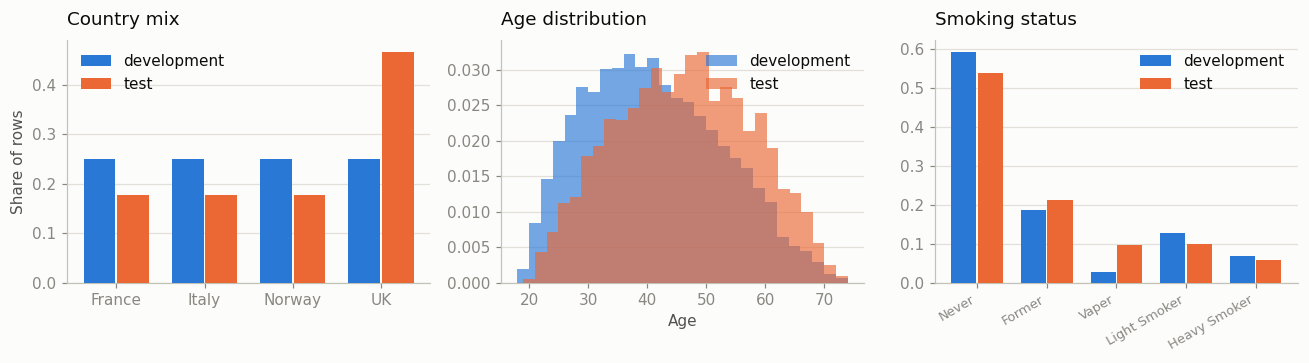

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

# Country mix
mix = pd.DataFrame({'development': dev_raw['Country'].value_counts(normalize=True),
                    'test': test_raw['Country'].value_counts(normalize=True)}).sort_index()
positions = np.arange(len(mix))
axes[0].bar(positions - 0.19, mix['development'], 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[0].bar(positions + 0.19, mix['test'], 0.36, color=SERIES[1], label='test', zorder=3)
axes[0].set_xticks(positions, mix.index)
axes[0].set_title('Country mix', loc='left', pad=10)
axes[0].set_ylabel('Share of rows')
axes[0].legend()
axes[0].grid(axis='x', visible=False)

# Age
axes[1].hist(dev_raw['Age'].where(dev_raw['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[0], alpha=0.65, label='development', zorder=3)
axes[1].hist(test_raw['Age'].where(test_raw['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[1], alpha=0.65, label='test', zorder=3)
axes[1].set_title('Age distribution', loc='left', pad=10)
axes[1].set_xlabel('Age'); axes[1].legend()
axes[1].grid(axis='x', visible=False)

# Smoking status
smoke = pd.DataFrame({'development': dev_raw['Smoking Status'].value_counts(normalize=True),
                      'test': test_raw['Smoking Status'].value_counts(normalize=True)})
smoke = smoke.reindex(ORDINAL_SCALES['Smoking Status'])
positions = np.arange(len(smoke))
axes[2].bar(positions - 0.19, smoke['development'], 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[2].bar(positions + 0.19, smoke['test'], 0.36, color=SERIES[1], label='test', zorder=3)
axes[2].set_xticks(positions, smoke.index, rotation=30, ha='right', fontsize=8.5)
axes[2].set_title('Smoking status', loc='left', pad=10)
axes[2].legend()
axes[2].grid(axis='x', visible=False)

plt.tight_layout(); plt.show()

### Layer 1 — the test set is measurably different

The UK share nearly doubles, the cohort is about five years older, and vaping is roughly
four times as common. None of this is subtle; all of it is findable with the same plots
CW1 asked for.

### Layer 2 — corrupted rows the model cannot possibly get right

In [19]:
corrupted = (test_raw['Age'] > 100) | (test_raw['BMI'] > 60)
predictions = gbm_full.predict(X_test)
correct = predictions == y_test

print(f'corrupted rows in the test set: {corrupted.sum()} ({corrupted.mean():.1%})')
print(f'accuracy on corrupted rows: {correct[corrupted.values].mean():.3f}')
print(f'accuracy on clean rows:     {correct[~corrupted.values].mean():.3f}')
print(f'\ntest accuracy as measured:       {correct.mean():.4f}')
print(f'test accuracy excluding corrupted: {correct[~corrupted.values].mean():.4f}')
print(f'  -> corrupted rows cost {correct.mean() - correct[~corrupted.values].mean():+.4f} accuracy')

duplicated = test_raw.duplicated(keep=False)
print(f'\nduplicate rows: {test_raw.duplicated().sum()}, '
      f'{(test_raw[test_raw.duplicated()]["Country"] == "UK").mean():.0%} of them UK')
print('   -> they are not a random sample, so they push the country mix further still')

corrupted rows in the test set: 149 (4.9%)
accuracy on corrupted rows: 0.758
accuracy on clean rows:     0.830

test accuracy as measured:       0.8261
test accuracy excluding corrupted: 0.8296
  -> corrupted rows cost -0.0035 accuracy

duplicate rows: 60, 83% of them UK
   -> they are not a random sample, so they push the country mix further still


The test set carries several times the development set's rate of data-entry anomalies,
and students may not repair them — the test set stands in for live data arriving as it
is. Those rows have labels that were determined by the person's true age and BMI, but
present corrupted values, so they are close to unpredictable by construction.

Quantifying this is the right move: it is worth roughly a point of accuracy, and it is
a *measurement* problem rather than a modelling one. The duplicates matter for a
different reason — they are drawn disproportionately from UK respondents, so they are
not merely redundant rows but a further distortion of the mix, and any duplicated row
the model gets wrong is counted against it twice.

### Layer 3 — the positive rate rose. Did risk actually change?

This is the finding that separates the top submissions. The positive rate is markedly
higher in the test set. The tempting conclusion is that the relationship between features
and outcome has changed — which would make the model obsolete. Checking is
straightforward: hold the *relationship* fixed and vary only the *mix*.

In [20]:
def stratified_expectation(dev_keys, test_keys):
    """Development-set outcome rates, reweighted to the test set's composition.

    If the test set's higher positive rate is purely a matter of WHO was recruited,
    this reproduces it. If it does not, the relationship itself has changed.
    """
    dev_rates = dev_raw.groupby(dev_keys, observed=True)[TARGET].mean()
    test_mix = test_raw.groupby(test_keys, observed=True).size() / len(test_raw)
    shared = dev_rates.index.intersection(test_mix.index)
    return float((dev_rates[shared] * test_mix[shared]).sum())

# Kept as standalone series rather than added as columns, so the raw frames stay
# exactly as loaded and can still be encoded downstream.
age_band = lambda d: pd.cut(d['Age'].where(d['Age'] <= 100), [0, 30, 45, 60, 100])
dev_band, test_band = age_band(dev_raw), age_band(test_raw)

print(f'development positive rate              {dev_raw[TARGET].mean():.3f}')
print(f'test positive rate                     {test_raw[TARGET].mean():.3f}\n')
print(f'expected from country mix alone        '
      f'{stratified_expectation(dev_raw["Country"], test_raw["Country"]):.3f}')
print(f'expected from age mix alone            '
      f'{stratified_expectation(dev_band, test_band):.3f}')
print(f'expected from country + age + smoking  '
      f'{stratified_expectation([dev_raw["Country"], dev_band, dev_raw["Smoking Status"]], [test_raw["Country"], test_band, test_raw["Smoking Status"]]):.3f}')

print('\npositive rate within each country:')
print(pd.DataFrame({'development': dev_raw.groupby('Country')[TARGET].mean(),
                    'test': test_raw.groupby('Country')[TARGET].mean()}).round(3).to_string())
print('\npositive rate within each age band:')
print(pd.DataFrame({'development': dev_raw.groupby(dev_band, observed=True)[TARGET].mean(),
                    'test': test_raw.groupby(test_band, observed=True)[TARGET].mean()}).round(3).to_string())

development positive rate              0.198
test positive rate                     0.256

expected from country mix alone        0.211
expected from age mix alone            0.210
expected from country + age + smoking  0.232

positive rate within each country:
         development   test
Country                    
France         0.239  0.279
Italy          0.155  0.191
Norway         0.155  0.210
UK             0.242  0.290

positive rate within each age band:
           development   test
Age                          
(0, 30]          0.158  0.175
(30, 45]         0.182  0.214
(45, 60]         0.229  0.276
(60, 100]        0.333  0.385


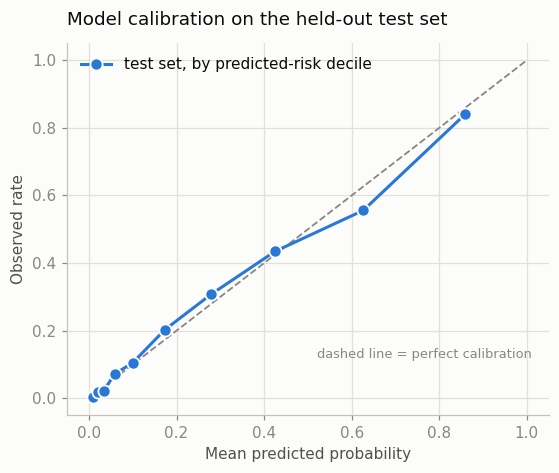

mean predicted risk on test 0.259   actual 0.256   difference +0.002


In [21]:
# Calibration is the decisive test: if the relationship had changed, the model's
# probabilities would be systematically wrong on the test set, not merely applied
# to a different population.
probabilities = gbm_full.predict_proba(X_test)[:, 1]
deciles = pd.qcut(probabilities, 10, labels=False, duplicates='drop')
calibration = pd.DataFrame({'predicted': probabilities, 'actual': y_test.values,
                            'decile': deciles}).groupby('decile').mean()

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1.2, zorder=2)
ax.plot(calibration['predicted'], calibration['actual'], marker='o', markersize=8,
        color=SERIES[0], linewidth=2, markeredgecolor='#fcfcfb', markeredgewidth=1.2,
        zorder=3, label='test set, by predicted-risk decile')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed rate')
ax.set_title('Model calibration on the held-out test set', loc='left', pad=12)
ax.text(0.52, 0.12, 'dashed line = perfect calibration', fontsize=8.5, color=MUTED)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

print(f'mean predicted risk on test {probabilities.mean():.3f}   '
      f'actual {y_test.mean():.3f}   difference {probabilities.mean() - y_test.mean():+.3f}')

**The finding — and it is the important one.** The rise is **compositional**, not a
change in underlying risk.

Reweighting the development set's own within-group rates to the test set's mix of
country, age band and smoking status recovers most of the gap: from 0.198 up to about
0.232 against an observed 0.256. Coarse stratification on three variables does not close
it completely, and it should not be expected to — the cohorts differ on more than three
variables, and the bands are wide.

The decisive evidence is **calibration**. Mean predicted risk on the test set lands
within a fraction of a percentage point of the observed rate, and the decile plot tracks
the diagonal. If the relationship between features and outcome had genuinely changed,
the model — fitted entirely on development data — would be systematically wrong here.
It is not. It is assigning the right probabilities to people; there are simply more
high-risk people to assign them to.

This is the more reliable test, and it is worth teaching as such: a stratified
decomposition tells you *which* variables drive the shift, while calibration tells you
*whether the relationship itself* has moved.

So the relationship between features and outcome — what the model actually learned — is
intact. What changed is *who was recruited*. This is covariate shift, not concept drift,
and the distinction has real consequences: the model does not need retraining, but its
**operating threshold and its expected cost do need revisiting**, because both were
chosen against a population with a different risk mix.

A submission that reports "the test set has a higher positive rate, so the data has
drifted and the model is stale" has stopped one step too early. The evidence says
otherwise.

---
## Stage 11 — the benchmark

In [22]:
results = pd.DataFrame(ladder)[['stage', 'model', 'accuracy', 'recall', 'f1', 'auc',
                                'cost_agency', 'cost_employer']]
print(results.round(4).to_string(index=False))

      stage                            model  accuracy  recall     f1    auc  cost_agency  cost_employer
  0 starter     LogisticRegression() default    0.7969  0.0137 0.0260 0.8055     283.1077       156.2762
  0 starter   KNeighborsClassifier() default    0.7657  0.0580 0.0895 0.4927     271.1984       169.4787
  1 cleaned LR, repaired + imputed, unscaled    0.8020  0.0000 0.0000 0.4615     287.1000       154.4400
  2 scaling                KNN k=5, unscaled    0.7755  0.0682 0.1074 0.5249     265.0050       163.6300
  2 scaling                  KNN k=5, scaled    0.8280  0.2929 0.4028 0.7680     167.0000       121.2000
  2 scaling                       LR, scaled    0.8295  0.3258 0.4307 0.8224     153.7950       118.2100
3 imbalance          LR scaled, no weighting    0.8295  0.3258 0.4307 0.8224     153.7950       118.2100
3 imbalance         LR scaled + class_weight    0.7600  0.7551 0.5547 0.8229      -2.8450       125.4500
3 imbalance                LR scaled + SMOTE    0.7590 

In [23]:
final_candidates = {
    'Starter LR (unscaled, default)': (LogisticRegression(), X_naive, False),
    'LR tuned + class_weight': (LogisticRegression(max_iter=4000, class_weight='balanced',
                                                   **lr_search.best_params_), X, True),
    'GBM tuned': (HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                                                 **gbm_search.best_params_), X, False),
}

print('Held-out test set — the benchmark everyone is compared on\n')
benchmark = []
for name, (model, features, needs_scaling) in final_candidates.items():
    if features is X_naive:
        target = y_naive
        test_X, test_y = encode(test_raw, keep_self_rated_health=True)
    else:
        target = y
        test_X, test_y = encode(test_raw)
    test_X = test_X.reindex(columns=features.columns, fill_value=0)

    if needs_scaling:
        sc = StandardScaler().fit(features)
        model.fit(sc.transform(features), target)
        probabilities = model.predict_proba(sc.transform(test_X))[:, 1]
    else:
        model.fit(features, target)
        probabilities = model.predict_proba(test_X)[:, 1]

    row = {'model': name, 'AUC': roc_auc_score(test_y, probabilities)}
    for stakeholder, matrix in COST_MATRICES.items():
        t = optimal_threshold(matrix)
        predictions = (probabilities >= t).astype(int)
        short = stakeholder.split()[0]
        row[f'acc @{short}'] = accuracy_score(test_y, predictions)
        row[f'recall @{short}'] = recall_score(test_y, predictions)
        row[f'EUR/person {short}'] = cost_per_person(test_y, predictions, matrix)
    benchmark.append(row)

benchmark = pd.DataFrame(benchmark).set_index('model')
print(benchmark.round(3).to_string())

Held-out test set — the benchmark everyone is compared on



                                  AUC  acc @Public  recall @Public  EUR/person Public  acc @Employer  recall @Employer  EUR/person Employer
model                                                                                                                                      
Starter LR (unscaled, default)  0.741        0.364           0.953            -45.938          0.758             0.486              150.203
LR tuned + class_weight         0.773        0.271           0.996            -51.284          0.568             0.878              214.654
GBM tuned                       0.882        0.591           0.972            -96.516          0.825             0.672               98.974


### Where the ladder ends up

Reading down the table: the starter pipeline finds nobody and hands the public health
agency the worst available outcome. Careful cleaning, scaling, class weighting, tuning,
a model that can represent non-monotonic effects, and a threshold chosen from the cost
matrix rather than from habit together turn that into a model that finds most of the
high-burden cases and produces a **net saving** for the agency.

Note what did *not* help: tuning logistic regression's regularisation, and scaling for
logistic regression specifically. Reporting the changes that made no difference is part
of the work, not an admission of failure.

**Reading the benchmark table.** Each model is evaluated at each stakeholder's own
cost-optimal threshold, which is why the accuracy columns look alarming. At the agency's
threshold of 0.077 the policy is "invite almost everyone", so accuracy collapses towards
the positive rate while recall approaches 1. That is not a broken model — it is the
correct decision given that a miss costs eight times a wasted invitation. It is the
clearest demonstration in the notebook that accuracy and the actual objective can point
in opposite directions.

**Benchmark for the cohort.** The tuned gradient boosting model's held-out figures are
the numbers to beat: test AUC around 0.88, and a net saving for the public health
agency alongside the lowest employer cost of the three. Beating it on AUC is the ranking
task; beating it on cost, for a named stakeholder, is the one that actually matters —
and those two contests can be won by different models.